# Does Geography Predict Regular Public Transit Use?

### A Random Forest analysis of Qualtrics latitude & longitude

**Course:** PSYCH 755 · UW–Madison  
**Project:** Communication apprehension (PRCA) persona framework  
**Notebook role:** Secondary research question — spatial predictors of transit behavior  

---

#### Research question

> Among Prolific↔Qualtrics **matched** respondents with complete PRCA ground truth, does approximate survey **geolocation** (`LocationLatitude`, `LocationLongitude`) predict whether an individual takes **public transportation regularly**?

**Outcome (regular transit):** `Q26` ∈ {`4-8 days a month`, `8 or more days a month`}  
**Features:** Qualtrics `LocationLatitude`, `LocationLongitude` only (primary model)  
**Model:** Balanced Random Forest with stratified *k*-fold cross-validation  

This notebook is designed for presentation: clear methods, visual EDA, formal metrics against null/country baselines, interpretable importances, and a distributable results card.


## 1. Analytic roadmap

| Section | Purpose |
|---|---|
| **2. Setup** | Paths, styling, package imports |
| **3. Data & sample** | Load File A/B/C matched cohort; define regular riders |
| **4. Spatial EDA** | Where regular vs non-regular riders appear in lat/lon space |
| **5. Model specification** | Random Forest pipeline & baselines |
| **6. Cross-validated performance** | ROC-AUC, PR-AUC, F1, confusion matrix vs chance/country |
| **7. Interpretation** | Gini + permutation importance; predicted probability surface |
| **8. Artifacts** | Tables/figures/JSON for slides and the manuscript |
| **9. Limitations** | IP geolocation caveats and confounding |

Supporting code: [`src/ca_personas/geo_transit_rf.py`](../src/ca_personas/geo_transit_rf.py)


## 2. Setup

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from ca_personas.geo_transit_rf import (
    GEO_FEATURES,
    run_geo_transit_rf_analysis,
    save_geo_transit_rf_artifacts,
)
from ca_personas.load import load_full_cohort
from ca_personas.paths import sibling_data_available
from ca_personas.transit_ca import PRIMARY_REGULAR_LABELS, Q26_STEM

# Presentation styling
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})
COLOR_REGULAR = "#C5050C"      # UW crimson
COLOR_NOT = "#3D3D3D"
COLOR_ACCENT = "#047A9C"

OUT = ROOT / "outputs" / "geo_transit_rf"
OUT.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

assert sibling_data_available(), (
    "Place File A/B/C under ../sibling_data/ before running this notebook."
)
print("Project root:", ROOT)
print("Output dir:", OUT)
print("Regular-rider Q26 labels:", sorted(PRIMARY_REGULAR_LABELS))
print("Q26 stem:", Q26_STEM)


Project root: /Users/morningstar/Desktop/Cold_Storage/psych755-jjb
Output dir: /Users/morningstar/Desktop/Cold_Storage/psych755-jjb/outputs/geo_transit_rf
Regular-rider Q26 labels: ['4-8 days a month', '8 or more days a month']
Q26 stem: In the last three months on how many days did you use public transportation (bus, train, tram, etc.)?


## 3. Data & sample construction

**Sources (private sibling folder — never committed):**

- `PRCAProlificExport_FileA.csv` + `FileB.csv` — stacked recruitment waves  
- `PRCAQualtricsExport_FileC.csv` — survey responses; merge on typed Prolific ID (`Q0`)

**Inclusion:** inner join with complete PRCA group + interpersonal items, non-missing latitude/longitude, and a usable `Q26` response.


In [2]:
participants, cleaning_report = load_full_cohort(join_how="inner")

analysis = run_geo_transit_rf_analysis(
    participants,
    n_splits=5,
    n_perm_repeats=30,
    random_state=42,
    grid_size=90,
)
frame = analysis["frame"]
summary = analysis["summary"]

print(json.dumps(cleaning_report, indent=2))
print()
print("Modeling N:", summary["sample"]["n"])
print(
    f"Regular riders: {summary['sample']['n_regular']} "
    f"({summary['sample']['prevalence']:.1%})"
)
frame.head()


{
  "n_prolific_raw": 262,
  "n_prolific_unique": 262,
  "n_qualtrics_raw": 273,
  "n_qualtrics_with_pid": 255,
  "n_qualtrics_complete_ca": 260,
  "n_joined": 252,
  "n_matched_both": 252,
  "n_analytic": 241,
  "n_dropped_missing_pid": 0,
  "n_dropped_incomplete_ca": 11,
  "n_dropped_unscorable_ca": 0,
  "n_dropped_unjoined": 31,
  "n_prolific_only": 10,
  "n_qualtrics_only": 21,
  "n_qualtrics_missing_pid": 18,
  "waves": {
    "B": 153,
    "A": 99
  },
  "notes": [
    "Normalized 19 DATA_EXPIRED Student status values to missing.",
    "Full Prolific waves (File A/B) omit Ethnicity / Nationality / Language; demos tier uses Age, Sex, Country of residence, and Student status.",
    "Analytic sample = Prolific\u2229Qualtrics with complete scorable PRCA group + interpersonal items.",
    "Merge coverage (pre-CA filter): 252 matched Prolific\u2229Qualtrics; 21 Qualtrics-only (incl. 18 blank Q0 test rows; disregard); 10 Prolific-only (disregard)."
  ]
}

Modeling N: 241
Regular riders: 

,participant_id,LocationLatitude,LocationLongitude,regular_transit,transit_group,Q26,Country of residence,Age,Sex,Employment status,Student status,y
0,ebab12e9878344fdc93a8c1cad27ff2f709e12b90f0496...,33.4158,-119.0493,False,not_regular,2-4 days a month,United States,36.0000,Male,Part-Time,Yes,0
1,b6954799ca47bc836ac02ab86e4710c3b0e096d7ace449...,34.7196,-81.5487,False,not_regular,Never,United States,41.0000,Male,Other,No,0
2,6ac07c3845b0ce5cac4ab3569ea70236b7cfa8fd51576e...,36.7595,-95.2947,False,not_regular,Never,United States,39.0000,Male,Full-Time,No,0
3,c67b3266ecd4af12979c1f67d1efffd0d3e9bfbc567d21...,51.9759,-1.8685,False,not_regular,Never,United Kingdom,61.0000,Male,Other,No,0
4,1cefb8d34b92489e8ffd9cf34c469964f0527b1cae33e0...,36.8237,-81.2130,False,not_regular,Never,United States,45.0000,Male,Full-Time,No,0


In [3]:
# Sample composition snapshot
comp = pd.DataFrame([
    {
        "metric": "Matched analytic sample (complete CA)",
        "value": cleaning_report["n_analytic"],
    },
    {
        "metric": "Modeling sample (complete lat/lon + Q26)",
        "value": summary["sample"]["n"],
    },
    {
        "metric": "Regular transit (weekly+)",
        "value": summary["sample"]["n_regular"],
    },
    {
        "metric": "Not regular",
        "value": summary["sample"]["n_not_regular"],
    },
])
comp


,metric,value
0,Matched analytic sample (complete CA),241
1,Modeling sample (complete lat/lon + Q26),241
2,Regular transit (weekly+),101
3,Not regular,140


## 4. Spatial exploratory analysis

We first ask whether regular and non-regular riders **occupy different regions** of the latitude–longitude plane — a necessary (not sufficient) condition for a geo-only classifier to succeed.


In [4]:
desc_group = analysis["descriptives_by_group"]
desc_group


,transit_group,n,mean_lat,std_lat,mean_lon,std_lon,median_lat,median_lon
0,not_regular,140,41.1018,9.9998,-69.0742,45.4711,40.0215,-81.3321
1,regular,101,43.0515,7.7346,-62.0013,44.2914,41.3856,-76.2681


In [5]:
if not analysis["descriptives_by_country"].empty:
    by_cty = analysis["descriptives_by_country"].head(12)
    by_cty
else:
    print("Country column not available in this frame.")


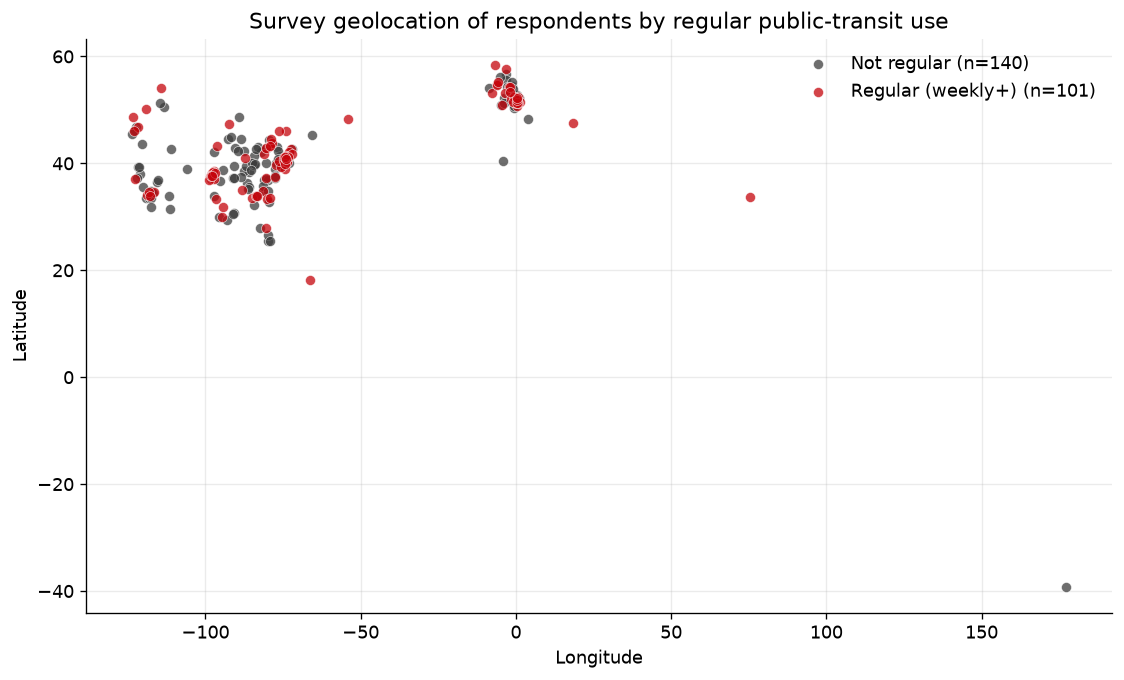

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.8))
for group, color, label in [
    ("not_regular", COLOR_NOT, "Not regular"),
    ("regular", COLOR_REGULAR, "Regular (weekly+)"),
]:
    sub = frame.loc[frame["transit_group"] == group]
    ax.scatter(
        sub["LocationLongitude"],
        sub["LocationLatitude"],
        s=36,
        alpha=0.75,
        c=color,
        edgecolors="white",
        linewidths=0.4,
        label=f"{label} (n={len(sub)})",
        zorder=3,
    )
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Survey geolocation of respondents by regular public-transit use")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUT / "fig_scatter_latlon_by_transit.png", bbox_inches="tight")
plt.show()


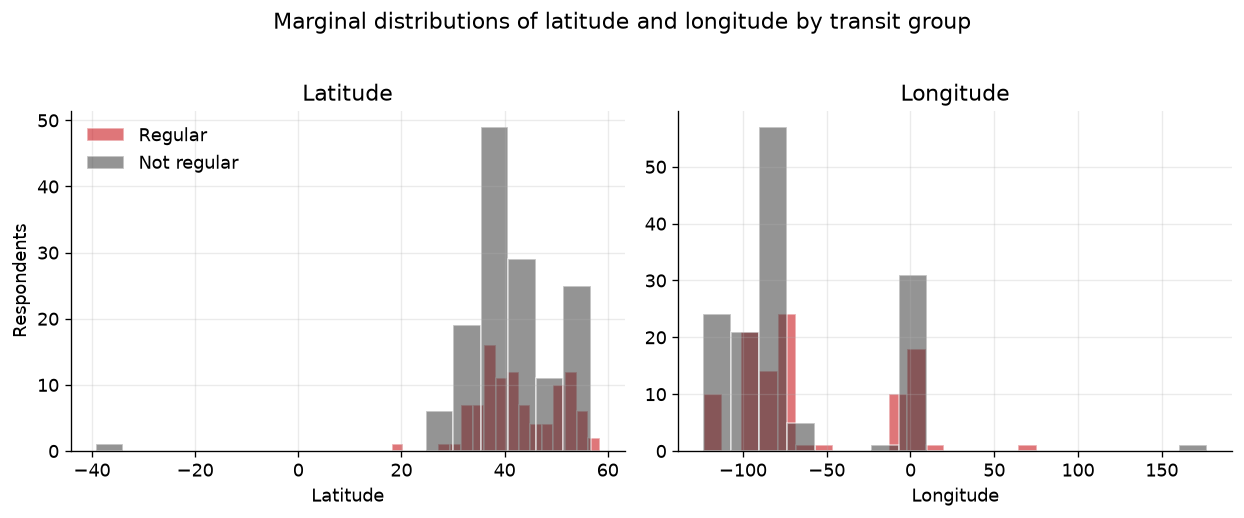

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, col, title in zip(
    axes,
    ["LocationLatitude", "LocationLongitude"],
    ["Latitude", "Longitude"],
):
    for group, color, label in [
        ("regular", COLOR_REGULAR, "Regular"),
        ("not_regular", COLOR_NOT, "Not regular"),
    ]:
        vals = frame.loc[frame["transit_group"] == group, col]
        ax.hist(vals, bins=18, alpha=0.55, color=color, label=label, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(title)
axes[0].set_ylabel("Respondents")
axes[0].legend()
fig.suptitle("Marginal distributions of latitude and longitude by transit group", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "fig_latlon_marginals_by_transit.png", bbox_inches="tight")
plt.show()


## 5. Model specification

### Primary model
- **Estimator:** `RandomForestClassifier` (500 trees, `min_samples_leaf=3`, `class_weight="balanced"`)
- **Features:** `LocationLatitude`, `LocationLongitude` (z-scored inside a pipeline)
- **Validation:** stratified 5-fold CV; out-of-fold predicted probabilities

### Baselines (for calibration of “predictive power”)
1. **Prevalence / chance** — constant score equal to class prevalence (ROC-AUC = 0.5)
2. **Majority class** — always predict the modal class
3. **Country-only Random Forest** — same estimator family on `Country of residence` (tests whether continuous lat/long adds signal beyond coarse geography)


In [8]:
print("Primary features:", GEO_FEATURES)
print("CV folds:", analysis["summary"]["cv_metrics"]["n_splits"])
analysis["pipeline"]


Primary features: ['LocationLatitude', 'LocationLongitude']
CV folds: 5


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['LocationLatitude','LocationLongitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 6. Cross-validated predictive performance

If latitude and longitude carry information about regular transit use, the geo-only Random Forest should achieve **ROC-AUC > 0.5** and, ideally, improve on the country-only baseline.


In [9]:
metrics = analysis["metrics_table"].copy()
show = [
    "model", "n", "prevalence", "roc_auc", "average_precision",
    "balanced_accuracy", "accuracy", "precision", "recall", "f1", "brier",
]
metrics[show]


,model,n,prevalence,roc_auc,average_precision,balanced_accuracy,accuracy,precision,recall,f1,brier
0,random_forest_lat_lon,241,0.4191,0.5511,0.4404,0.5324,0.5353,0.4522,0.5149,0.4815,0.2731
1,prevalence_prob,241,0.4191,0.5000,0.4191,0.5000,0.5809,0.0000,0.0000,0.0000,0.2435
2,majority_class,241,0.4191,0.5000,0.4191,0.5000,0.5809,0.0000,0.0000,0.0000,0.4191
3,random_forest_country_only,241,0.4191,0.5492,0.4476,0.5615,0.5851,0.5060,0.4158,0.4565,0.2487


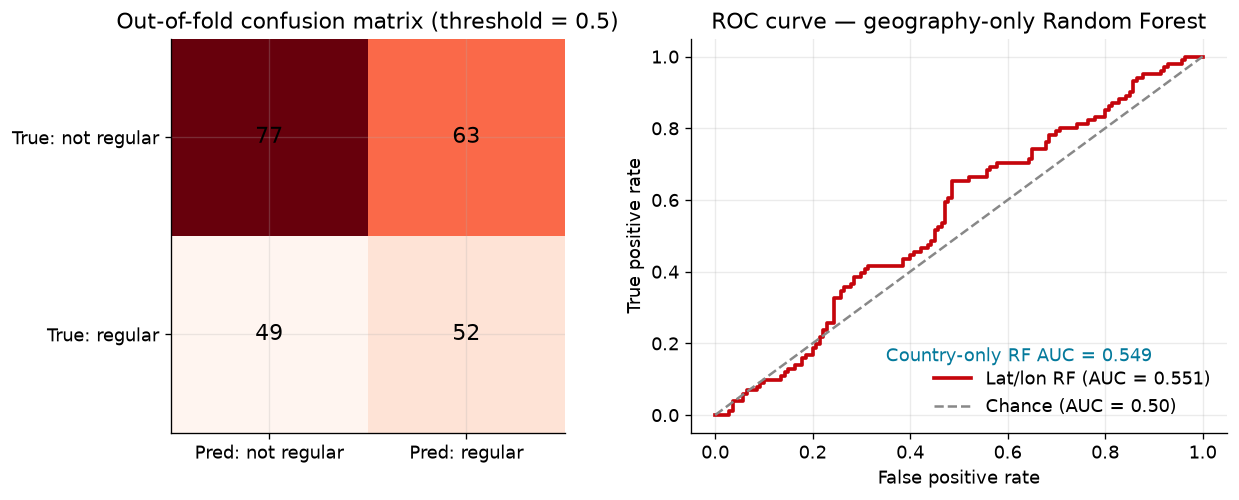

In [10]:
rf_m = analysis["summary"]["cv_metrics"]
cm = np.array([[rf_m["tn"], rf_m["fp"]], [rf_m["fn"], rf_m["tp"]]], dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.3))

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm, cmap="Reds")
ax.set_xticks([0, 1], ["Pred: not regular", "Pred: regular"])
ax.set_yticks([0, 1], ["True: not regular", "True: regular"])
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, f"{int(val)}", ha="center", va="center", fontsize=13, color="black")
ax.set_title("Out-of-fold confusion matrix (threshold = 0.5)")

# ROC
ax = axes[1]
roc = analysis["roc"]
ax.plot(roc["fpr"], roc["tpr"], color=COLOR_REGULAR, lw=2.2,
        label=f"Lat/lon RF (AUC = {rf_m['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="#888888", label="Chance (AUC = 0.50)")
if analysis["country_baseline"] is not None:
    c_auc = analysis["country_baseline"]["metrics"]["roc_auc"]
    # country ROC not stored pointwise; mark AUC in legend via horizontal note
    ax.text(0.35, 0.15, f"Country-only RF AUC = {c_auc:.3f}", color=COLOR_ACCENT)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — geography-only Random Forest")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT / "fig_rf_confusion_and_roc.png", bbox_inches="tight")
plt.show()


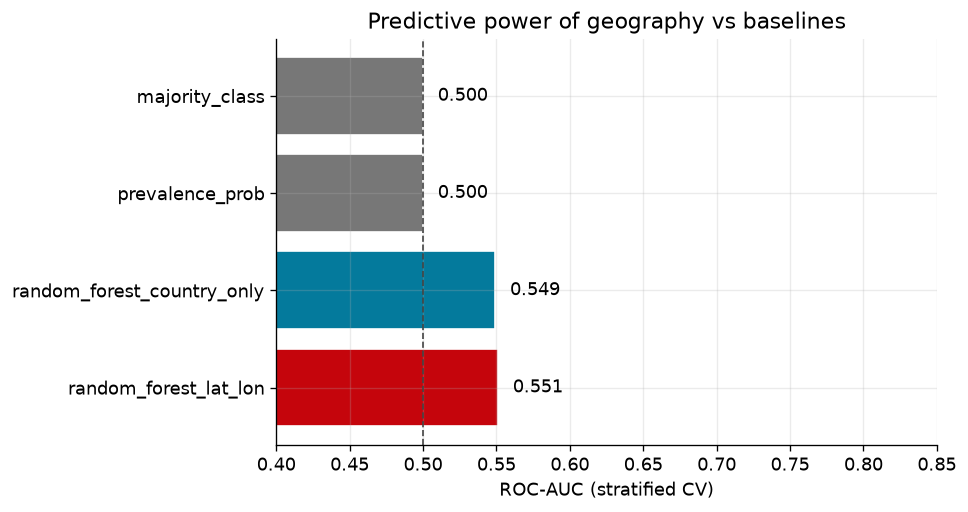

In [11]:
# Metric lift chart vs baselines
plot_df = metrics.set_index("model").loc[
    [m for m in ["random_forest_lat_lon", "random_forest_country_only", "prevalence_prob", "majority_class"]
     if m in metrics["model"].values]
]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
vals = plot_df["roc_auc"]
colors = [COLOR_REGULAR if i == 0 else COLOR_ACCENT if "country" in idx else "#777777"
          for i, idx in enumerate(vals.index)]
bars = ax.barh(range(len(vals)), vals.values, color=colors, edgecolor="white")
ax.set_yticks(range(len(vals)), vals.index)
ax.axvline(0.5, color="#444444", ls="--", lw=1, label="Chance")
ax.set_xlabel("ROC-AUC (stratified CV)")
ax.set_xlim(0.4, max(0.85, float(vals.max()) + 0.05))
ax.set_title("Predictive power of geography vs baselines")
for bar, v in zip(bars, vals.values):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center")
fig.tight_layout()
fig.savefig(OUT / "fig_rf_auc_vs_baselines.png", bbox_inches="tight")
plt.show()


In [12]:
print("=== Verdict ===")
print(json.dumps(summary["verdict"], indent=2))
print()
print("Primary CV metrics:")
for k in ["roc_auc", "average_precision", "balanced_accuracy", "f1", "brier"]:
    print(f"  {k:20s} {rf_m[k]:.4f}")


=== Verdict ===
{
  "roc_auc": 0.5511315417256011,
  "beats_chance_auc_0_5": true,
  "beats_prevalence_baseline": true,
  "delta_auc_vs_country": 0.0019094766619518477,
  "interpretation": "Lat/long Random Forest CV ROC-AUC = 0.551 (country-only AUC = 0.549). Geography shows modest signal above chance; interpret cautiously."
}

Primary CV metrics:
  roc_auc              0.5511
  average_precision    0.4404
  balanced_accuracy    0.5324
  f1                   0.4815
  brier                0.2731


## 7. What does the forest use? Importances & decision surface

Even with only two features, impurity and permutation importances show the **relative contribution** of latitude vs longitude. The probability surface visualizes how predicted regular-transit risk varies over the observed geographic extent.


In [13]:
imp = analysis["gini_importance"].merge(
    analysis["permutation_importance"], on="feature"
)
imp


,feature,importance_gini,importance_perm_mean,importance_perm_std
0,LocationLongitude,0.5112,0.3349,0.0316
1,LocationLatitude,0.4888,0.2600,0.0208


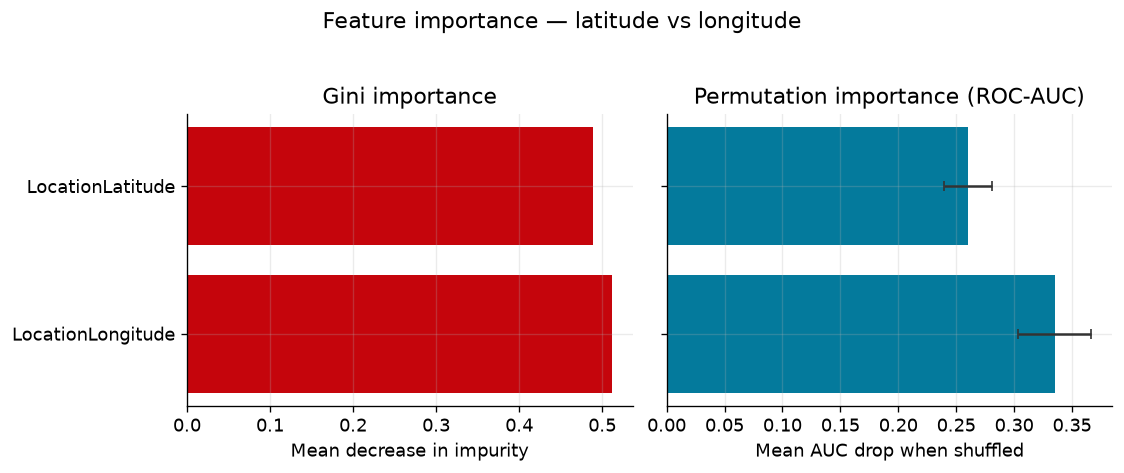

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)
axes[0].barh(imp["feature"], imp["importance_gini"], color=COLOR_REGULAR)
axes[0].set_title("Gini importance")
axes[0].set_xlabel("Mean decrease in impurity")
axes[1].barh(
    imp["feature"],
    imp["importance_perm_mean"],
    xerr=imp["importance_perm_std"],
    color=COLOR_ACCENT,
    ecolor="#333333",
    capsize=3,
)
axes[1].set_title("Permutation importance (ROC-AUC)")
axes[1].set_xlabel("Mean AUC drop when shuffled")
fig.suptitle("Feature importance — latitude vs longitude", y=1.03)
fig.tight_layout()
fig.savefig(OUT / "fig_rf_feature_importance.png", bbox_inches="tight")
plt.show()


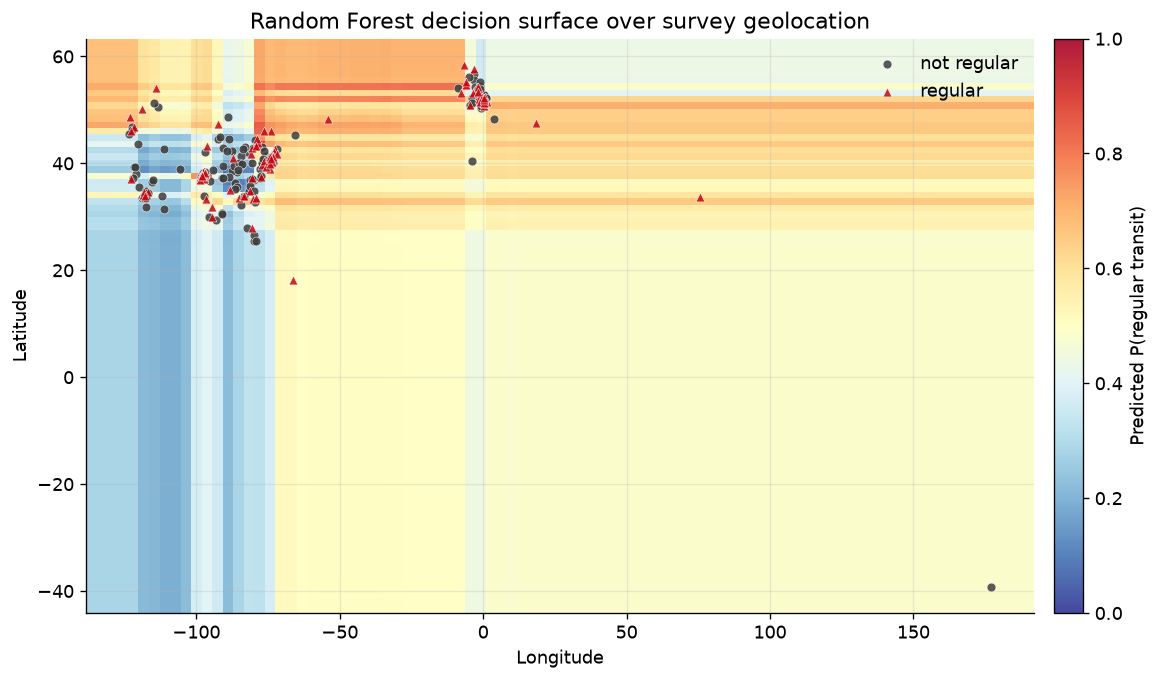

In [15]:
grid = analysis["grid"]
lat = np.sort(grid["LocationLatitude"].unique())
lon = np.sort(grid["LocationLongitude"].unique())
Z = grid.pivot(index="LocationLatitude", columns="LocationLongitude", values="p_regular").values

fig, ax = plt.subplots(figsize=(9.8, 5.8))
extent = [lon.min(), lon.max(), lat.min(), lat.max()]
im = ax.imshow(
    Z,
    origin="lower",
    extent=extent,
    aspect="auto",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1,
    alpha=0.9,
)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Predicted P(regular transit)")
for group, color, marker in [
    ("not_regular", COLOR_NOT, "o"),
    ("regular", COLOR_REGULAR, "^") ,
]:
    sub = frame.loc[frame["transit_group"] == group]
    ax.scatter(
        sub["LocationLongitude"],
        sub["LocationLatitude"],
        s=28,
        c=color,
        marker=marker,
        edgecolors="white",
        linewidths=0.35,
        alpha=0.85,
        label=group.replace("_", " "),
        zorder=3,
    )
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Random Forest decision surface over survey geolocation")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUT / "fig_rf_decision_surface.png", bbox_inches="tight")
plt.show()


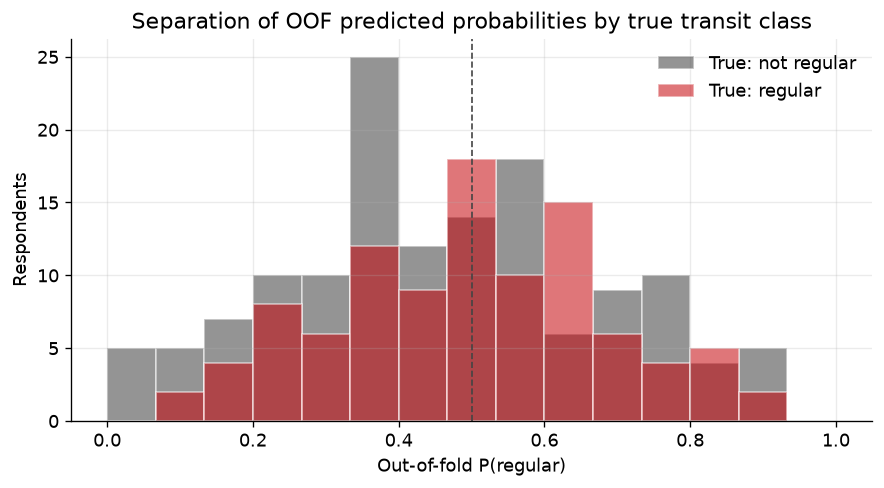

In [16]:
# Reliability-style view: OOF predicted probability by true class
oof = analysis["oof"]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for yval, color, label in [
    (0, COLOR_NOT, "True: not regular"),
    (1, COLOR_REGULAR, "True: regular"),
]:
    ax.hist(
        oof.loc[oof["y"] == yval, "y_prob_rf"],
        bins=np.linspace(0, 1, 16),
        alpha=0.55,
        color=color,
        label=label,
        edgecolor="white",
    )
ax.axvline(0.5, color="#444444", ls="--", lw=1)
ax.set_xlabel("Out-of-fold P(regular)")
ax.set_ylabel("Respondents")
ax.set_title("Separation of OOF predicted probabilities by true transit class")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig_oof_probability_separation.png", bbox_inches="tight")
plt.show()


## 8. Export artifacts for presentation & distribution

All tables, the results card, and figures are written to `outputs/geo_transit_rf/` (gitignored).


In [17]:
paths = save_geo_transit_rf_artifacts(analysis, OUT)
# Persist cleaned cohort used upstream as well
processed = ROOT / "data" / "processed"
processed.mkdir(parents=True, exist_ok=True)
participants.to_csv(processed / "participants_scored.csv", index=False)
(processed / "cleaning_report.json").write_text(json.dumps(cleaning_report, indent=2))

card = json.loads(paths["results_card"].read_text())
print(json.dumps(card, indent=2))
print()
print("Artifacts:")
for k, p in paths.items():
    print(f"  {k:24s} {p}")
print("Figures:")
for p in sorted(OUT.glob("fig_*.png")):
    print(" ", p.name)


{
  "secondary_rq": "Does Qualtrics survey geolocation (latitude & longitude) predict whether a matched respondent takes public transportation regularly?",
  "sample": {
    "n": 241,
    "n_regular": 101,
    "n_not_regular": 140,
    "prevalence": 0.4190871369294606
  },
  "cv_metrics": {
    "n": 241,
    "prevalence": 0.4190871369294606,
    "threshold": 0.5,
    "accuracy": 0.5352697095435685,
    "balanced_accuracy": 0.5324257425742575,
    "precision": 0.45217391304347826,
    "recall": 0.5148514851485149,
    "f1": 0.48148148148148145,
    "roc_auc": 0.5511315417256011,
    "average_precision": 0.44044880542881926,
    "brier": 0.2730653627661484,
    "tn": 77,
    "fp": 63,
    "fn": 49,
    "tp": 52,
    "model": "random_forest_lat_lon",
    "n_splits": 5,
    "features": [
      "LocationLatitude",
      "LocationLongitude"
    ]
  },
  "baselines": {
    "prevalence_roc_auc": 0.5,
    "country_only_roc_auc": 0.5492220650636492
  },
  "verdict": {
    "roc_auc": 0.5511315417

## 9. Limitations & interpretation guidance

1. **Approximate geolocation.** Qualtrics `LocationLatitude` / `LocationLongitude` reflect survey/IP geolocation, not a verified residential address or transit catchment.
2. **Observational design.** A predictive association between coordinates and regular transit use is **not** a causal effect of place.
3. **Confounding by country / urbanicity.** Continuous lat/long may proxy national sample composition, city density, or car dependence. The country-only baseline helps contextualize—but does not eliminate—this confounding.
4. **Outcome coarseness.** “Regular” is a thresholded reading of `Q26` (weekly-or-more). Sensitivity to alternate cutoffs is examined in `secondary_rq_transit_ca.ipynb`.
5. **Sample scope.** Results apply to the Prolific↔Qualtrics matched analytic cohort for this project, not to a census of transit users.

---

### Slide-ready takeaway (auto-filled)

The next cell prints AUC / conclusion lines from `summary` so this section never carries blank placeholders.


In [18]:
sample = summary["sample"]
verdict = summary["verdict"]
baselines = summary["baselines"]
auc = float(verdict["roc_auc"])
country_auc = baselines.get("country_only_roc_auc")
print("RQ: Can lat/long predict regular public-transit use in the matched cohort?")
print(
    f"N / prevalence: n={sample['n']} · regular={sample['n_regular']} · "
    f"prevalence={sample['prevalence']:.3f}"
)
country_txt = (
    f"{float(country_auc):.3f}"
    if country_auc is not None and country_auc == country_auc
    else "n/a"
)
print(f"Lat/lon RF ROC-AUC: {auc:.3f} · Country-only AUC: {country_txt} · Chance: 0.50")
print(
    "Conclusion: Geography "
    + ("DOES" if verdict.get("beats_chance_auc_0_5") else "does NOT")
    + " carry above-chance predictive signal for regular transit "
    "under the primary Q26 definition."
)
# Rank lat vs lon from the permutation-importance table when present.
if "importances" in analysis and isinstance(analysis["importances"], pd.DataFrame):
    imp = analysis["importances"]
    if {"feature", "permutation_importance_mean"} <= set(imp.columns):
        ranked = (
            imp.set_index("feature")["permutation_importance_mean"]
            .reindex(["LocationLongitude", "LocationLatitude"])
            .dropna()
        )
        if len(ranked):
            print(f"Higher permutation importance: {ranked.idxmax()}")
print("Interpretation:", verdict.get("interpretation"))


RQ: Can lat/long predict regular public-transit use in the matched cohort?
N / prevalence: n=241 · regular=101 · prevalence=0.419
Lat/lon RF ROC-AUC: 0.551 · Country-only AUC: 0.549 · Chance: 0.50
Conclusion: Geography DOES carry above-chance predictive signal for regular transit under the primary Q26 definition.
Interpretation: Lat/long Random Forest CV ROC-AUC = 0.551 (country-only AUC = 0.549). Geography shows modest signal above chance; interpret cautiously.
